In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df_estudiantes = pd.read_excel(r'data\Evaluaciones estudiantes.xlsx')

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df_estudiantes.head(3))


,id_estudiante,id_seccion,participante,socios,Programa,coordi,ugel,region,provincia,distrito,nom_ie,seccion_nivel,grado,seccion,periodo,cuadernillo,area_evaluacion,habilidad,estudiante,suma_puntaje,tot_preguntas,porcentaje_promedio,resultado_evaluacion
0,888f9482-4f06-4d11-90cb-a80166a373f3,f36acef6-31e9-4ae8-bb95-04b75fb7ab1f,"QUISPE BUENDIA, YERY DANNY","Antamina,Franco Nevada,Wheaton Precious Metals",PDL,"AGURTO CLAVO, TANIA STEFANI",UGEL HUARI,ANCASH,HUARI,SAN PEDRO DE CHANA,86843,Primaria,Pri-6xto,Única,Inicio,TFA - Clima de aula,Clima de aula,Se valoran los aportes y las ideas de los estu...,"GARAY LAGUNA, DAYLIN YANINA",20.0,5,80.0,Satisfactorio
1,888f9482-4f06-4d11-90cb-a80166a373f3,f36acef6-31e9-4ae8-bb95-04b75fb7ab1f,"QUISPE BUENDIA, YERY DANNY","Antamina,Franco Nevada,Wheaton Precious Metals",PDL,"AGURTO CLAVO, TANIA STEFANI",UGEL HUARI,ANCASH,HUARI,SAN PEDRO DE CHANA,86843,Primaria,Pri-6xto,Única,Inicio,TFA - Clima de aula,Clima de aula,Se fomentan relaciones alentadoras y de apoyo,"GARAY LAGUNA, DAYLIN YANINA",10.0,3,67.0,Satisfactorio
2,888f9482-4f06-4d11-90cb-a80166a373f3,f36acef6-31e9-4ae8-bb95-04b75fb7ab1f,"QUISPE BUENDIA, YERY DANNY","Antamina,Franco Nevada,Wheaton Precious Metals",PDL,"AGURTO CLAVO, TANIA STEFANI",UGEL HUARI,ANCASH,HUARI,SAN PEDRO DE CHANA,86843,Primaria,Pri-6xto,Única,Inicio,TFA - Clima de aula,Clima de aula,Se establece un entorno de aprendizaje atractivo,"GARAY LAGUNA, DAYLIN YANINA",17.0,4,85.0,Satisfactorio


In [6]:
df_estudiantes.info()

<class 'pandas.DataFrame'>
RangeIndex: 97464 entries, 0 to 97463
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_estudiante         97464 non-null  str    
 1   id_seccion            97464 non-null  str    
 2   participante          97464 non-null  str    
 3   socios                97464 non-null  str    
 4   Programa              97464 non-null  str    
 5   coordi                97464 non-null  str    
 6   ugel                  97464 non-null  str    
 7   region                97464 non-null  str    
 8   provincia             97464 non-null  str    
 9   distrito              97464 non-null  str    
 10  nom_ie                97464 non-null  str    
 11  seccion_nivel         97464 non-null  str    
 12  grado                 97464 non-null  str    
 13  seccion               97464 non-null  str    
 14  periodo               97464 non-null  str    
 15  cuadernillo           97464 no

In [27]:
# Agrupamos por escuela
eda_escuelas = df_estudiantes.groupby(['nom_ie','grado','Programa']).agg({
    'id_estudiante': 'count',           # Cantidad de alumnos por escuela
    'porcentaje_promedio': 'mean',      # Rendimiento promedio
    'suma_puntaje': 'mean',             # Puntaje promedio
    'region': 'first',                  # Para mantener la ubicación
    'ugel': 'first'
}).rename(columns={'id_estudiante': 'n_estudiantes'}).reset_index()

# Ver las primeras filas del nuevo resumen
eda_escuelas.head()

,nom_ie,grado,Programa,n_estudiantes,porcentaje_promedio,suma_puntaje,region,ugel
0,048 ELVA BARBA TRINIDAD,Ini-3ero,PDL,108,61.092593,21.027778,ANCASH,UGEL BOLOGNESI
1,099,Ini-3ero,PDL,162,57.314815,20.024691,ANCASH,UGEL HUARI
2,109,Ini-5nto,PDL,90,50.711111,17.355556,ANCASH,UGEL HUARI
3,112,Ini-4rto,QM,198,55.393939,19.252525,ANCASH,UGEL HUARI
4,112,Ini-5nto,PDL,162,65.635802,23.623457,ANCASH,UGEL HUARI


In [32]:
eda_escuelas.describe()

,n_estudiantes,porcentaje_promedio,suma_puntaje
count,129.000000,127.000000,127.000000
mean,755.534884,35.577103,12.119030
std,886.970062,18.246065,7.494148
min,2.000000,0.523893,1.446429
25%,144.000000,21.815150,6.431570
50%,396.000000,29.377656,9.026042
75%,1088.000000,53.892806,20.106357
max,4672.000000,81.000000,34.000000


In [28]:
eda_escuelas.shape

(129, 8)

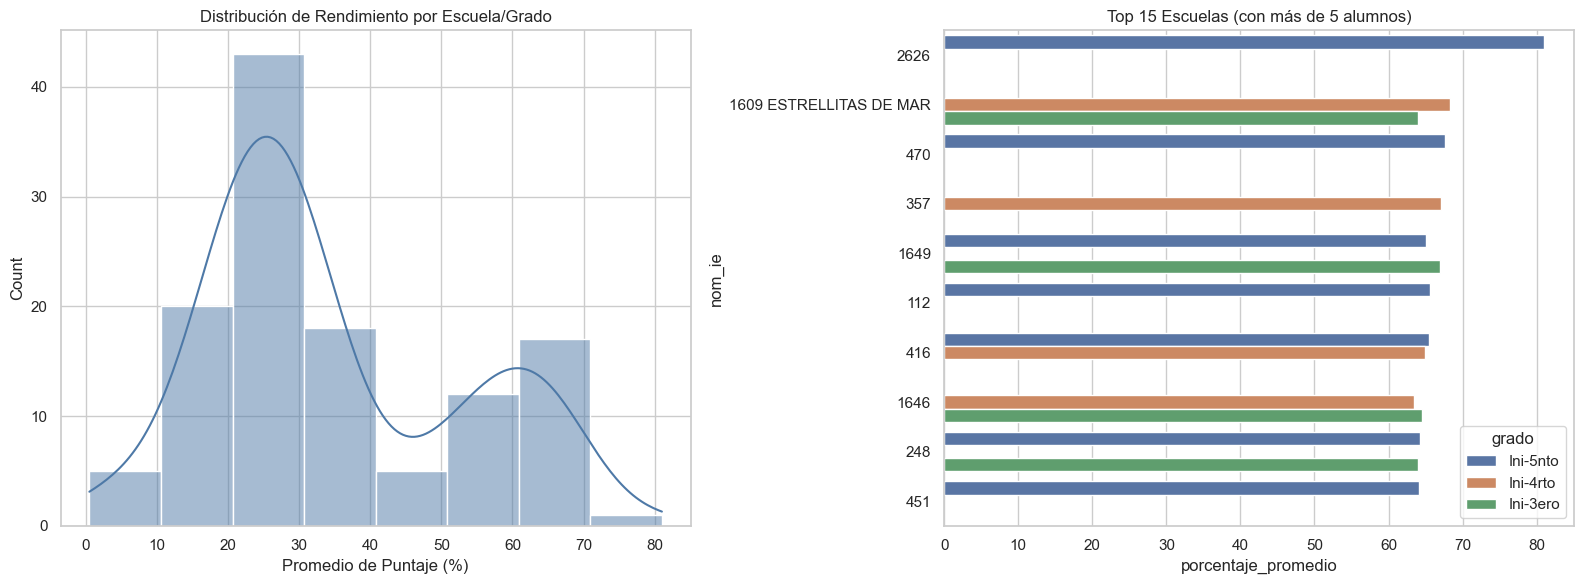

In [23]:
# 2. Configuración de la figura correctamente
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico A: Distribución de promedios por escuela
sns.histplot(eda_escuelas['porcentaje_promedio'], kde=True, ax=axes[0], color='#4e79a7')
axes[0].set_title('Distribución de Rendimiento por Escuela/Grado')
axes[0].set_xlabel('Promedio de Puntaje (%)')

# Gráfico B: Top 15 Escuelas con mejor rendimiento (solo escuelas con > 5 alumnos para evitar sesgos)
top_escuelas = eda_escuelas[eda_escuelas['n_estudiantes'] > 5].nlargest(15, 'porcentaje_promedio')
sns.barplot(data=top_escuelas, x='porcentaje_promedio', y='nom_ie', hue='grado', ax=axes[1])
axes[1].set_title('Top 15 Escuelas (con más de 5 alumnos)')

plt.tight_layout()
plt.show()

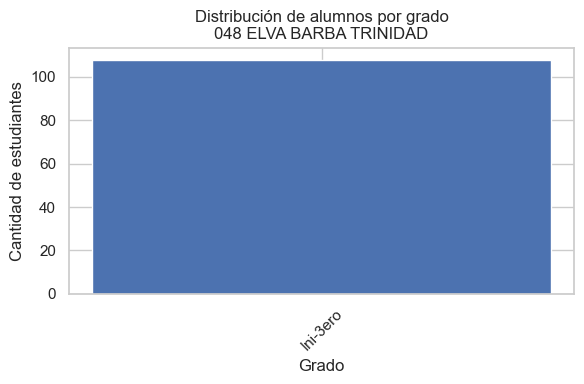

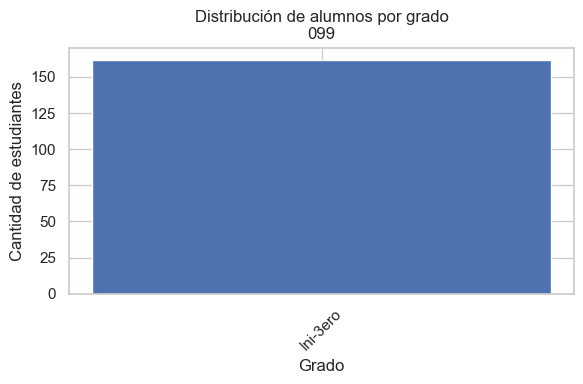

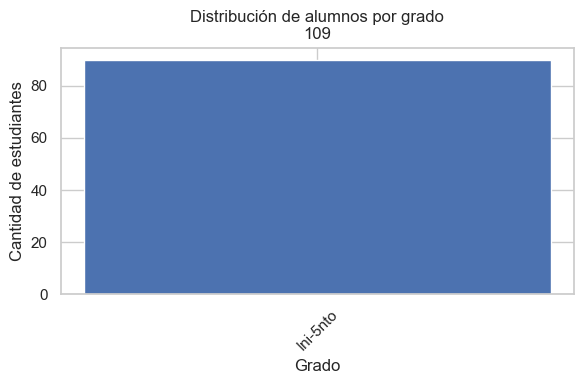

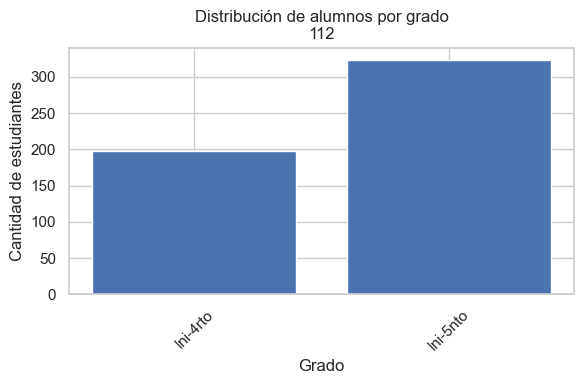

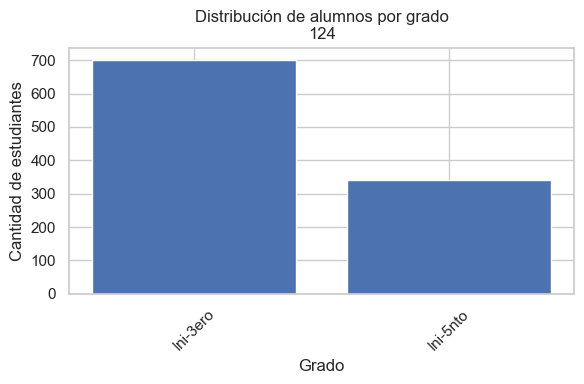

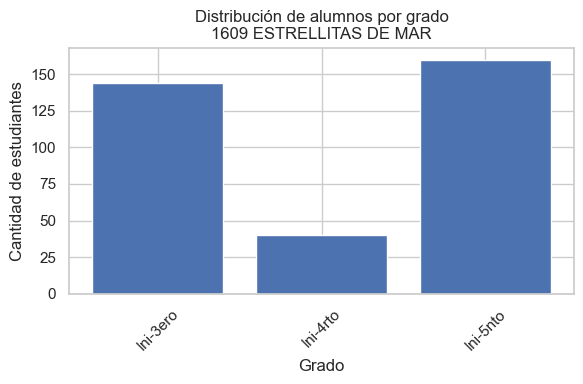

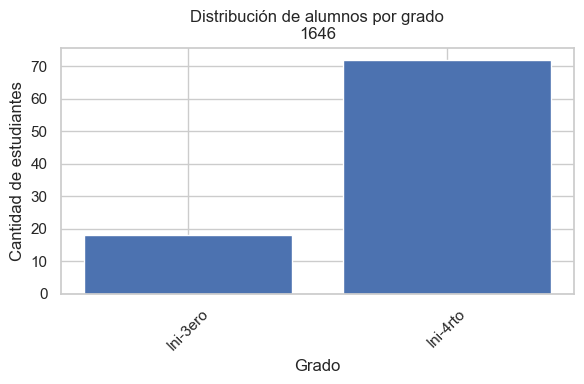

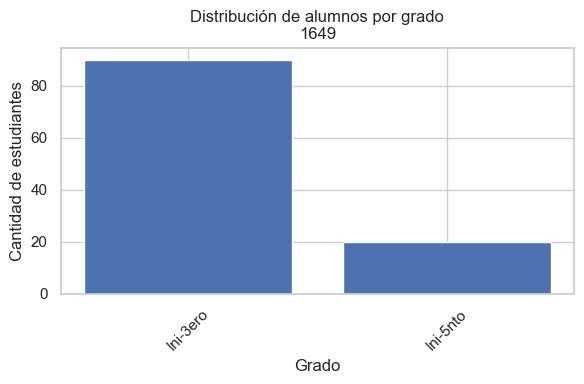

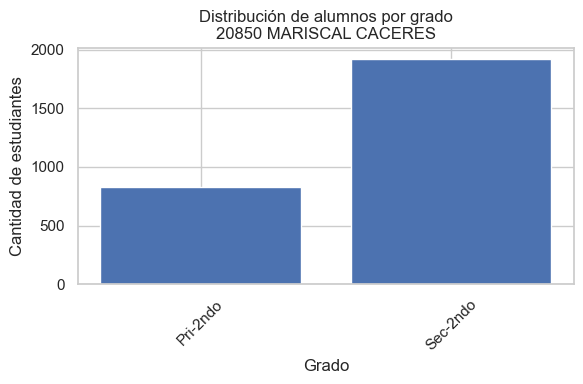

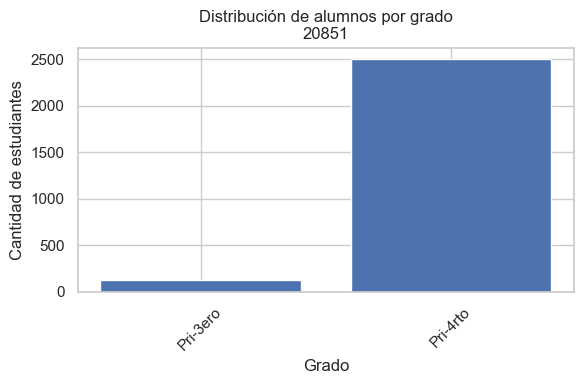

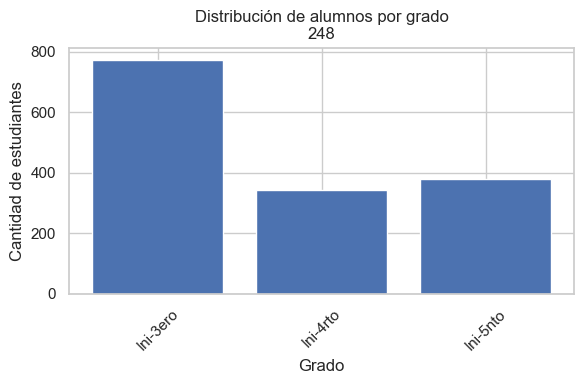

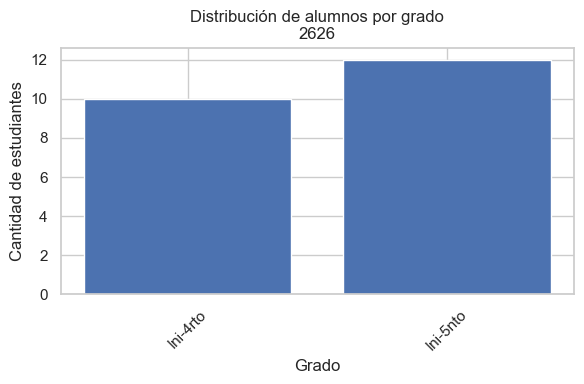

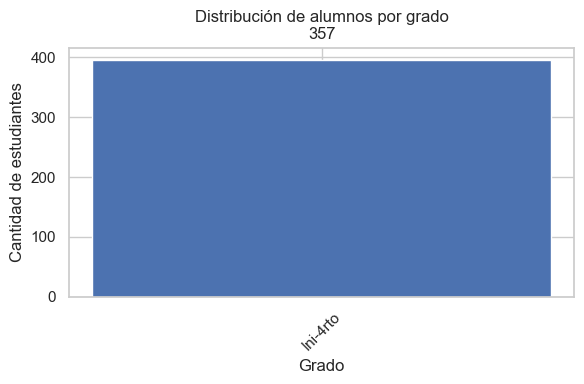

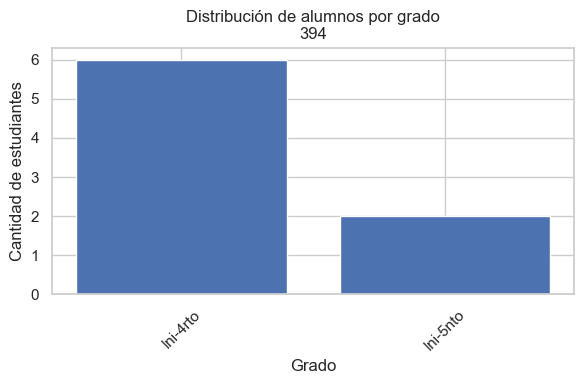

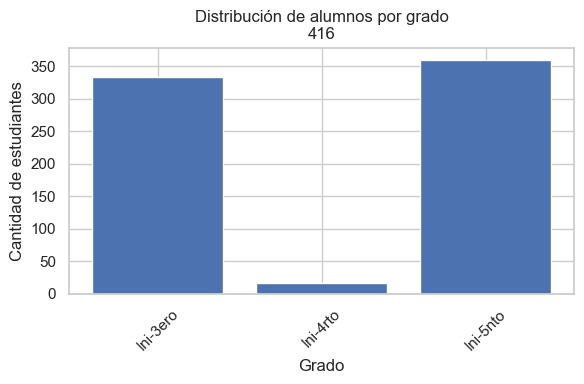

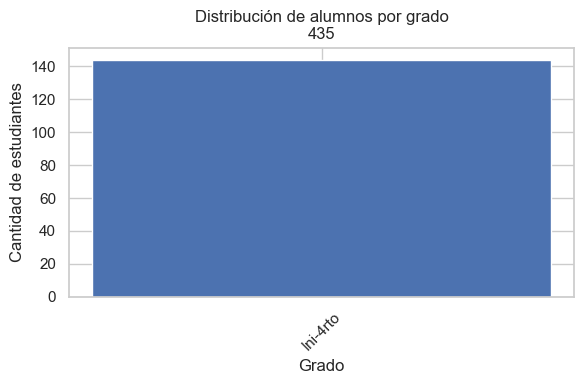

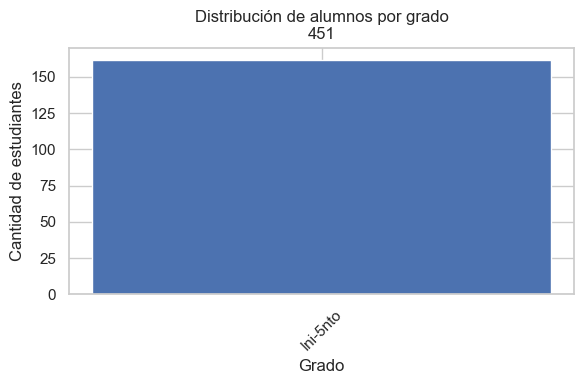

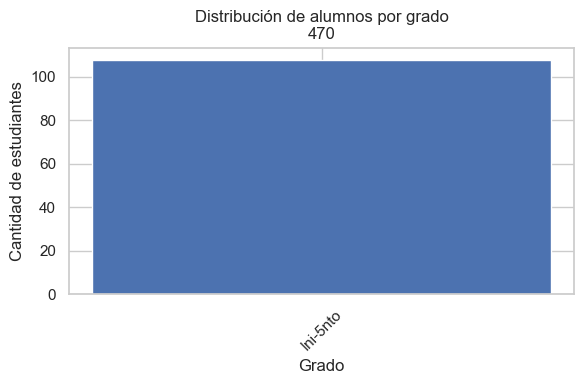

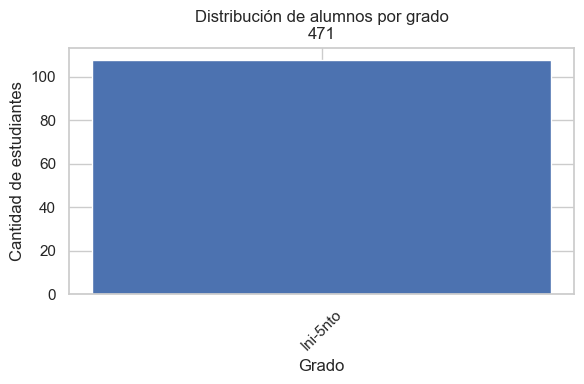

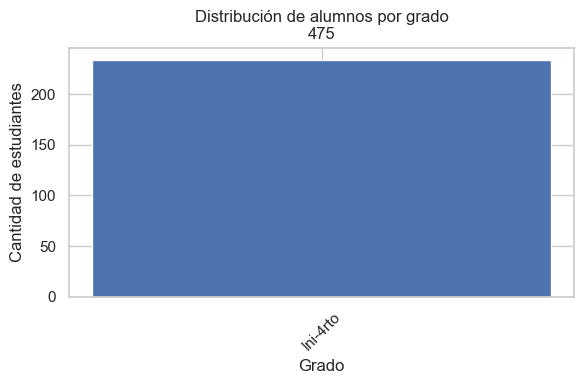

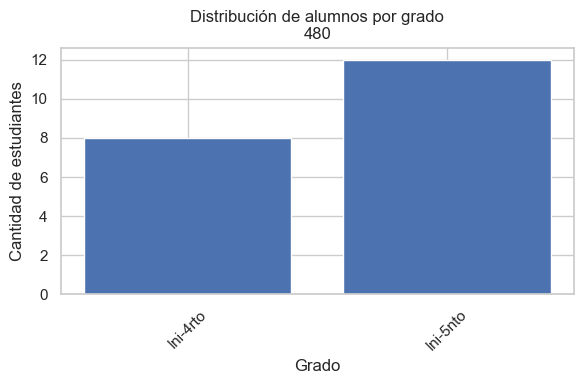

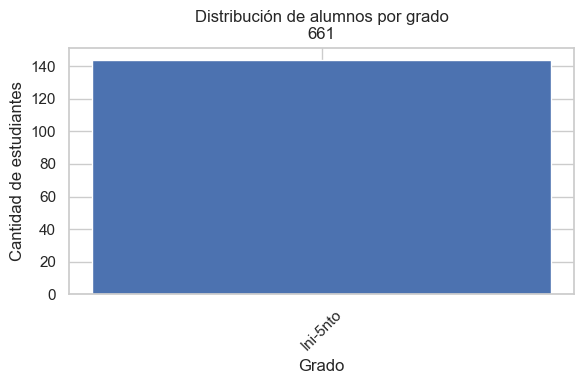

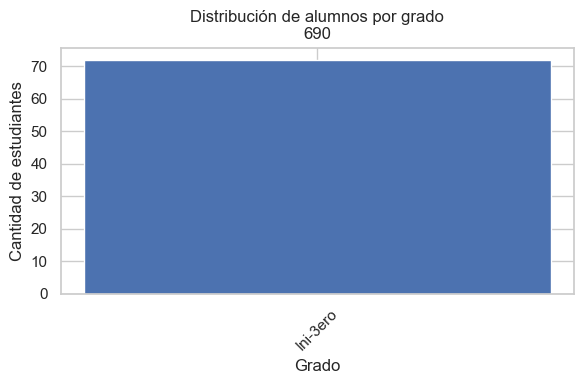

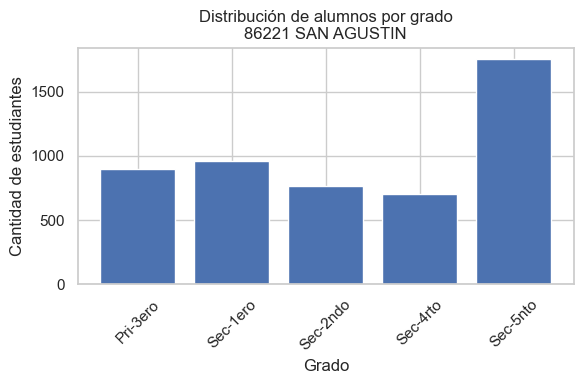

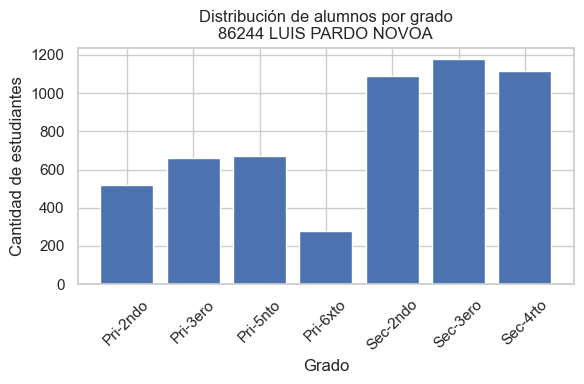

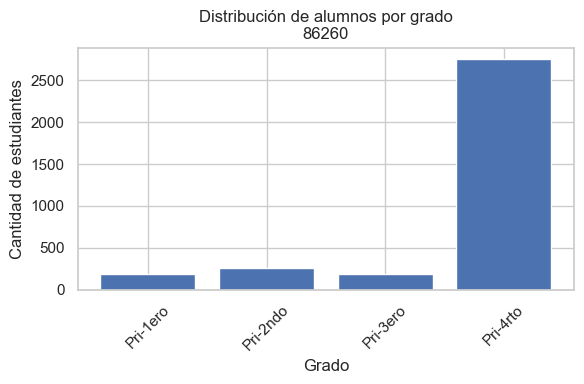

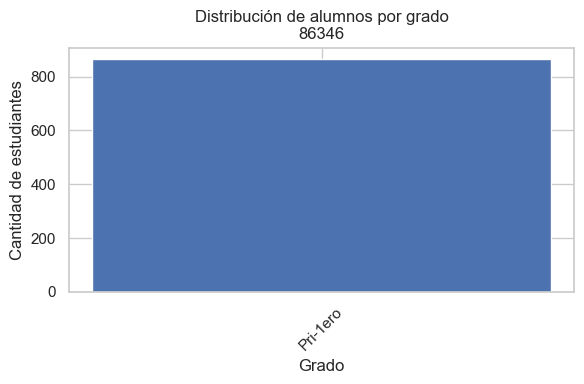

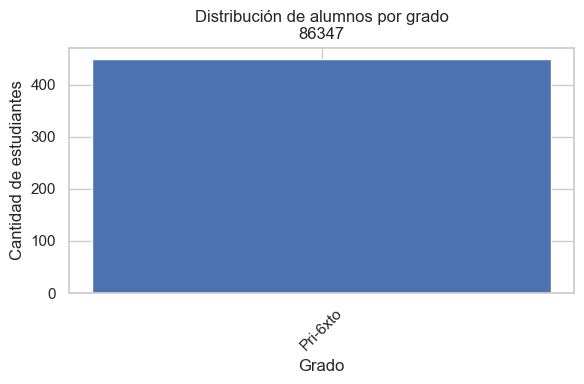

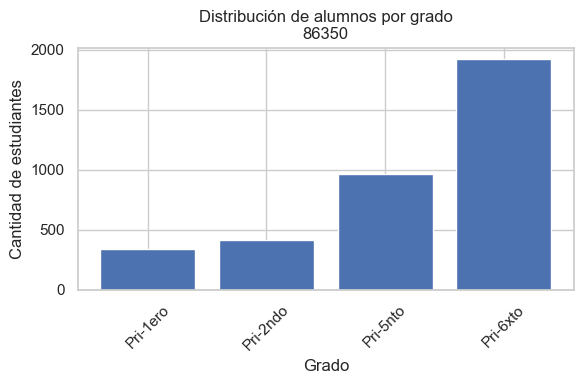

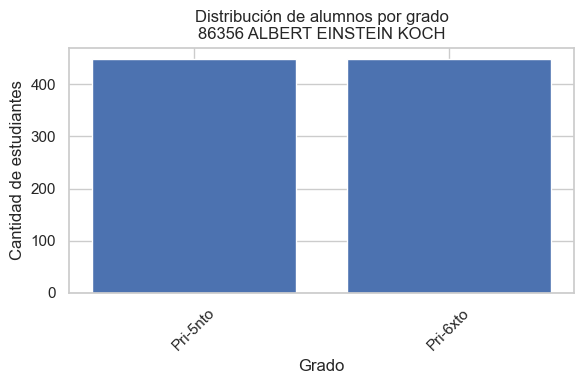

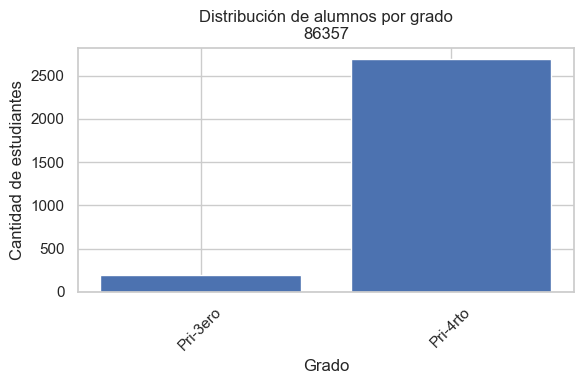

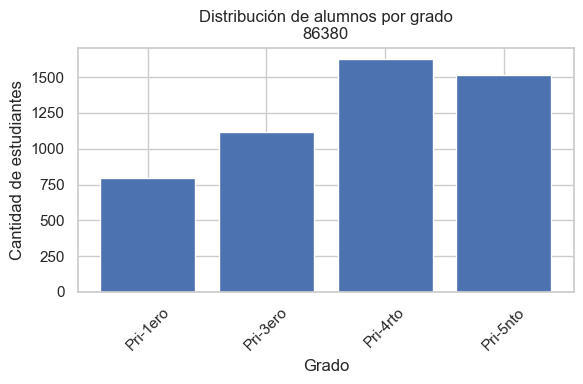

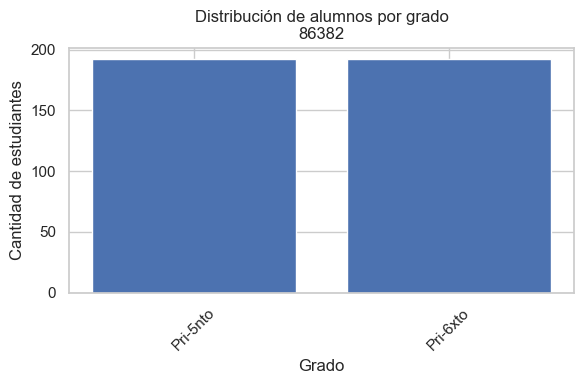

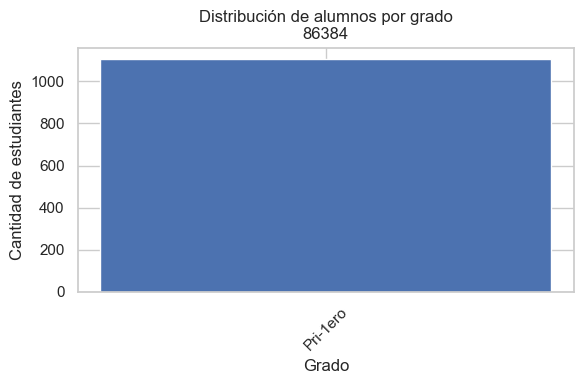

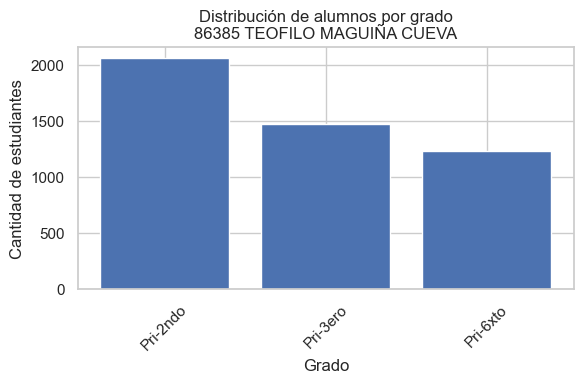

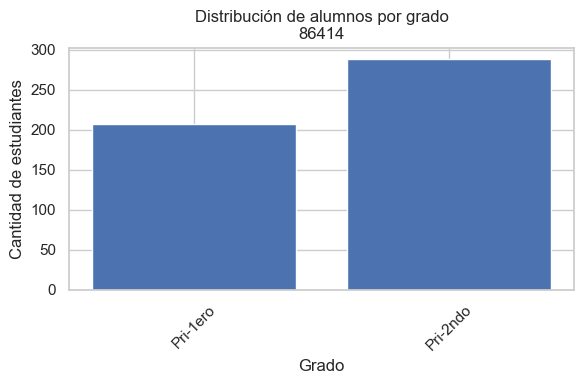

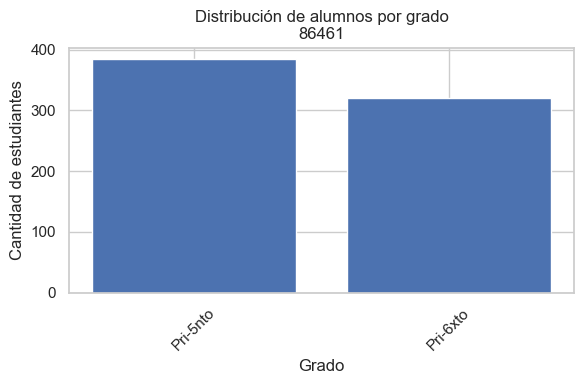

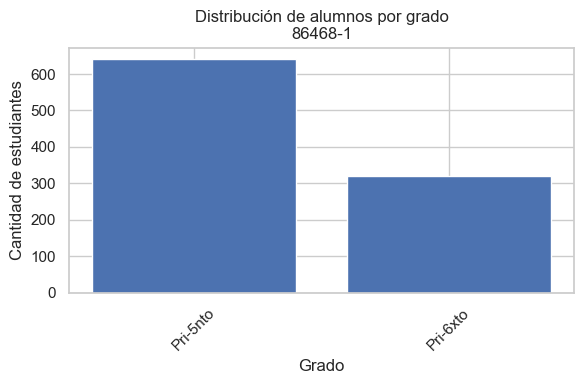

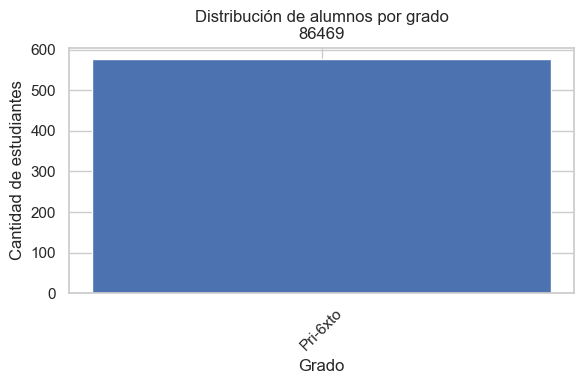

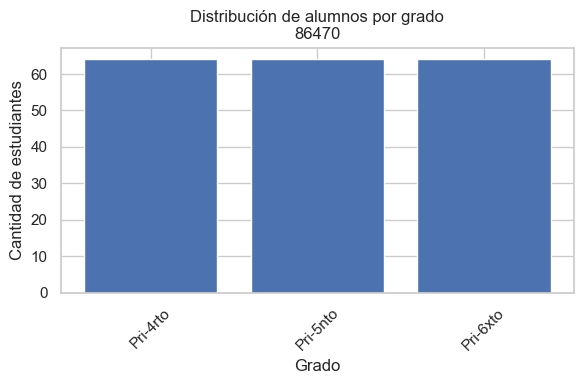

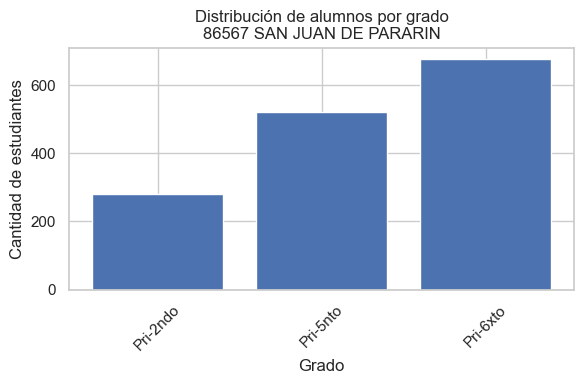

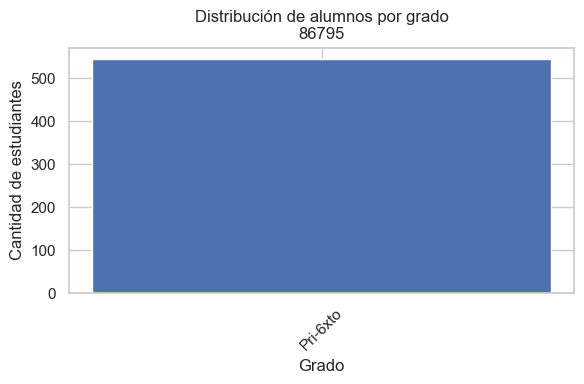

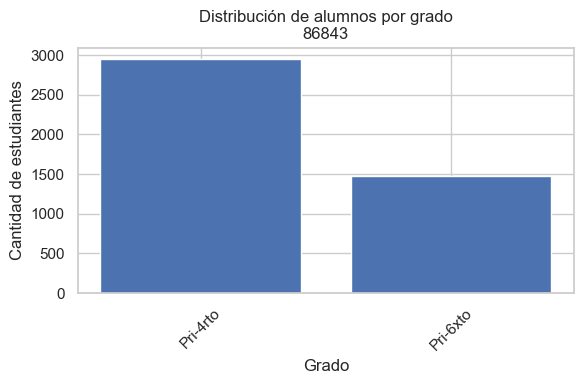

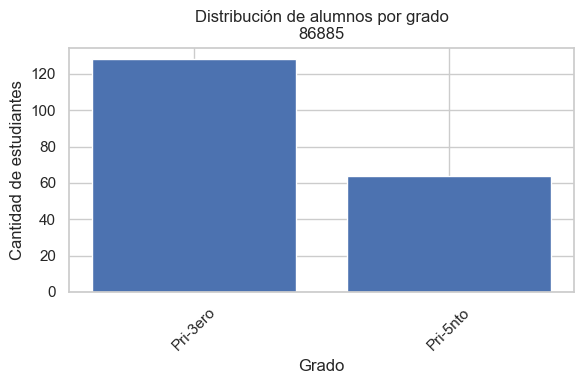

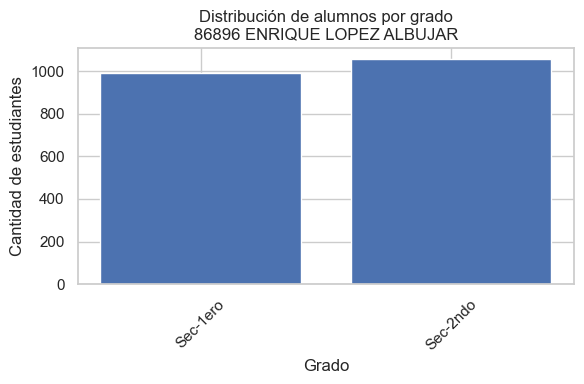

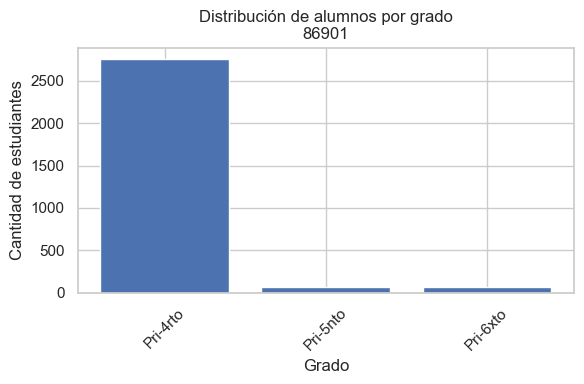

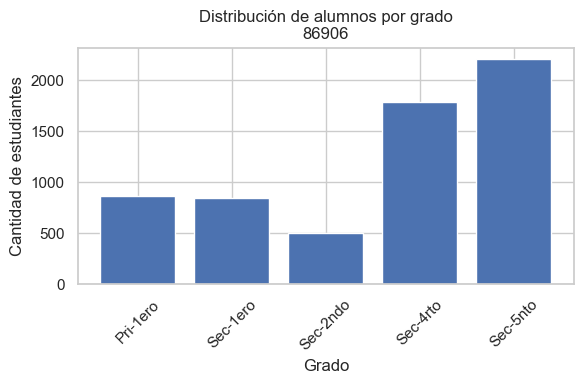

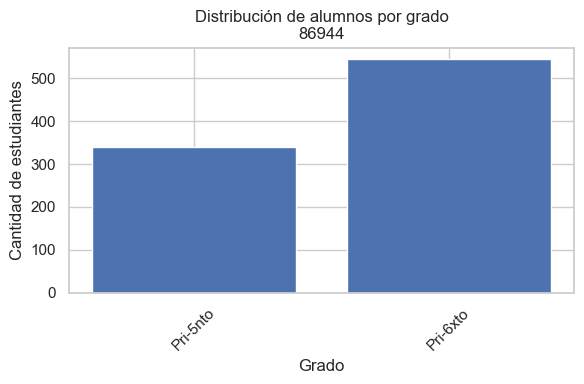

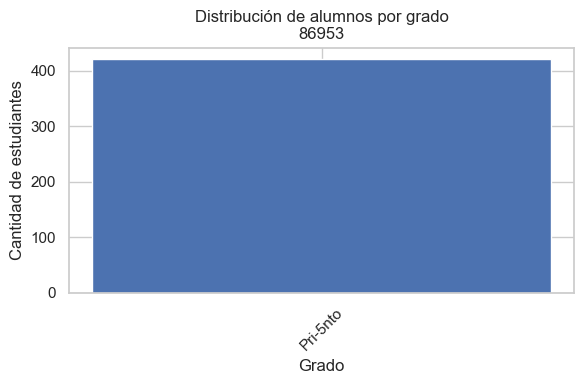

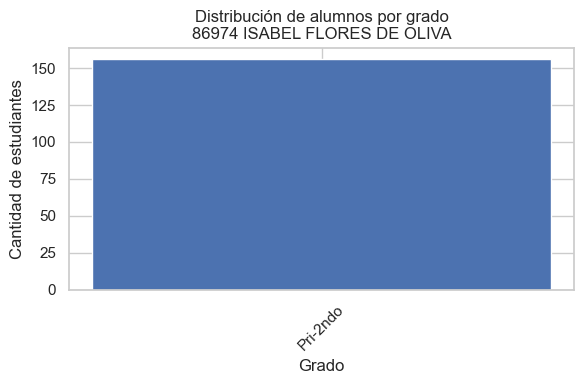

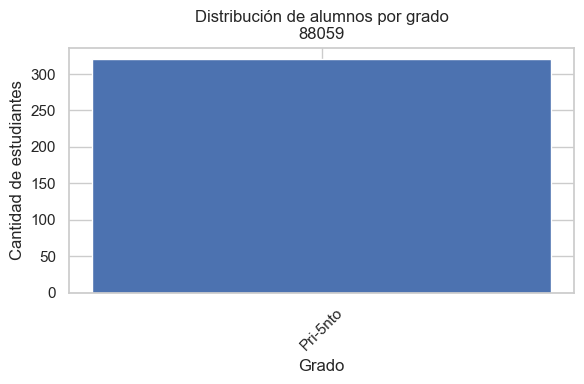

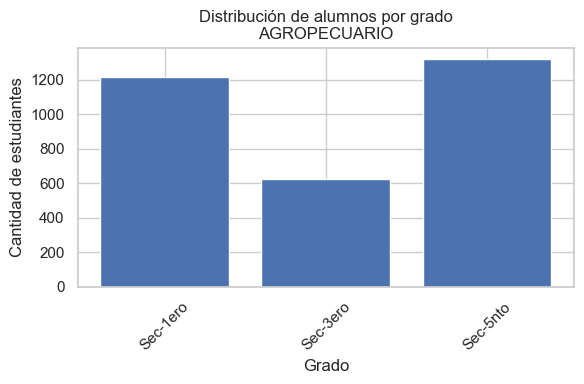

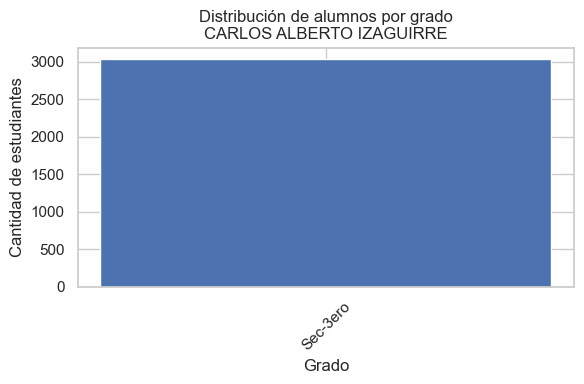

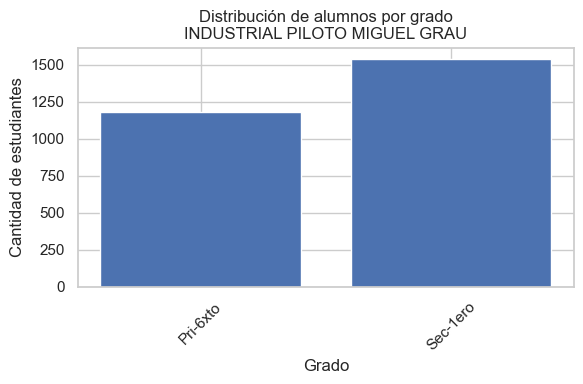

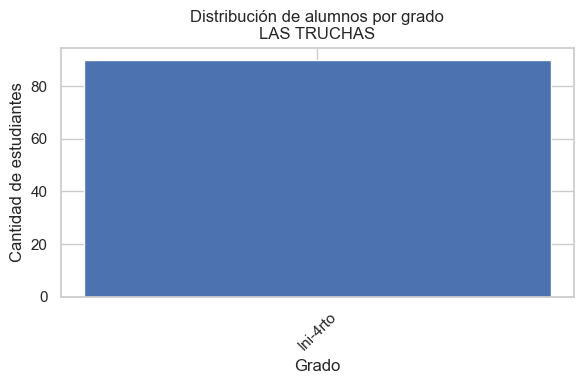

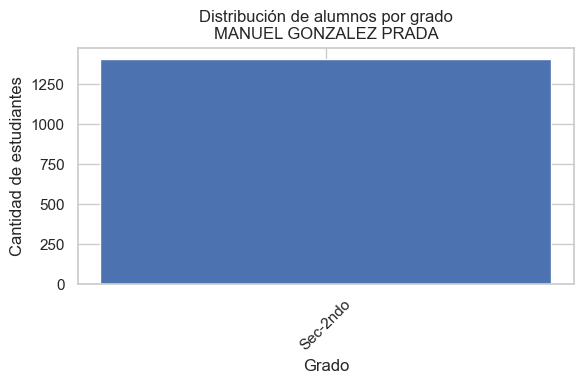

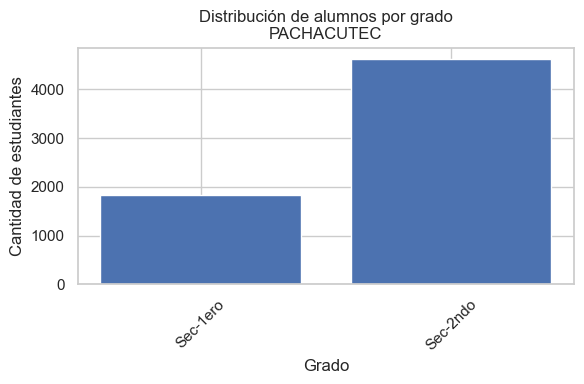

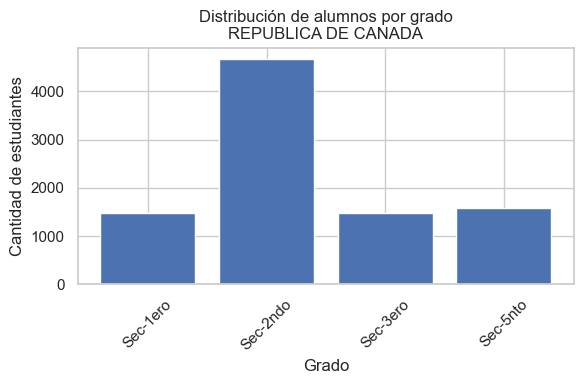

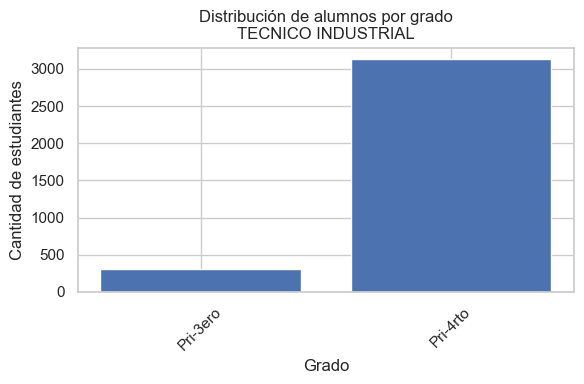

In [25]:
import matplotlib.pyplot as plt

# Lista de colegios
colegios = eda_escuelas['nom_ie'].unique()

for colegio in colegios:
    
    df_temp = eda_escuelas[eda_escuelas['nom_ie'] == colegio]
    
    plt.figure(figsize=(6,4))
    
    plt.bar(
        df_temp['grado'],
        df_temp['n_estudiantes']
    )
    
    plt.title(f'Distribución de alumnos por grado\n{colegio}')
    plt.xlabel('Grado')
    plt.ylabel('Cantidad de estudiantes')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

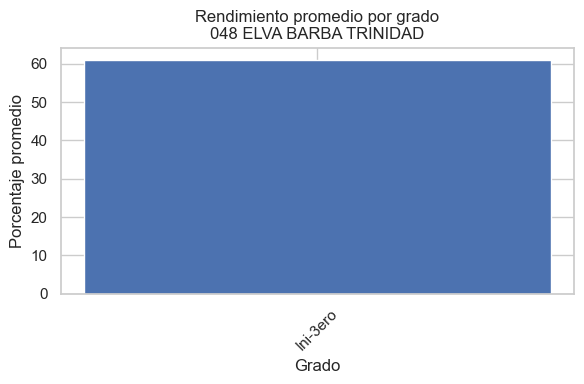

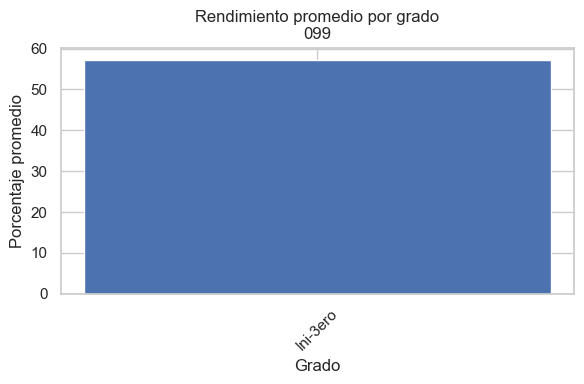

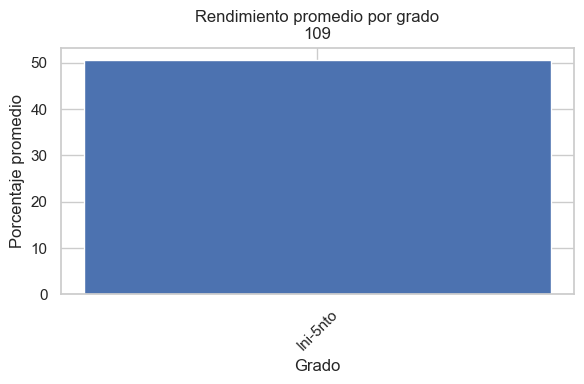

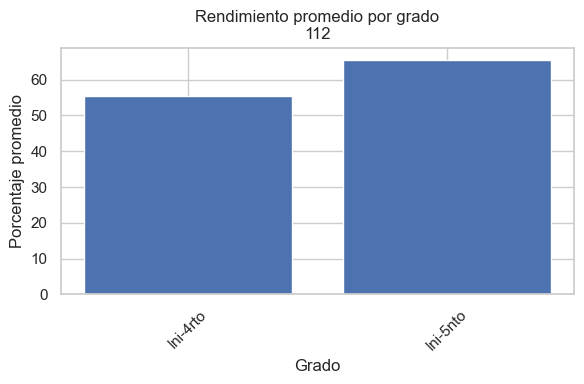

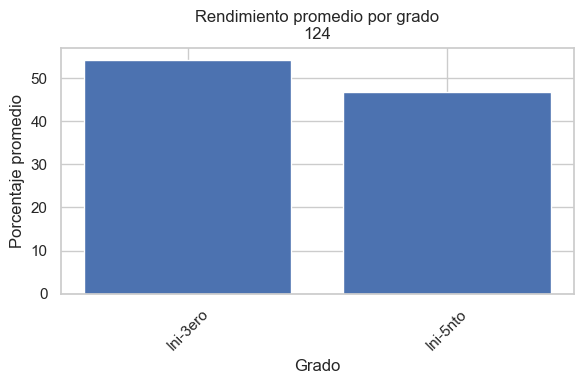

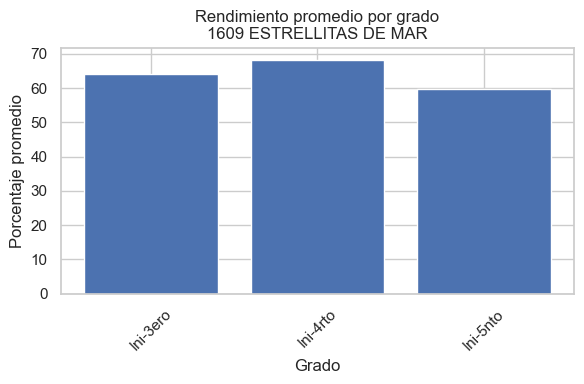

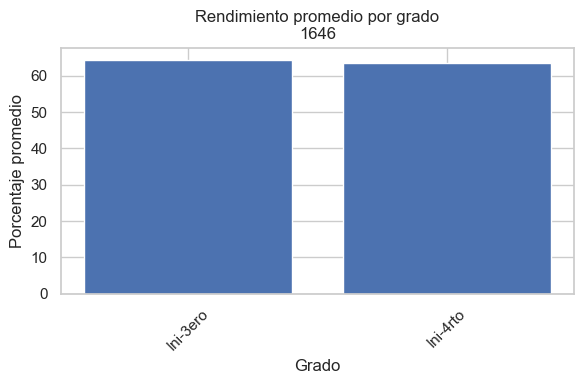

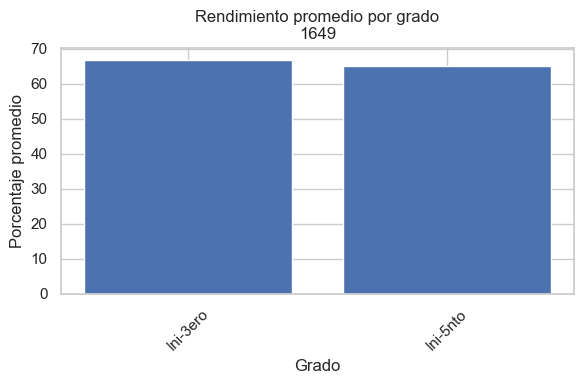

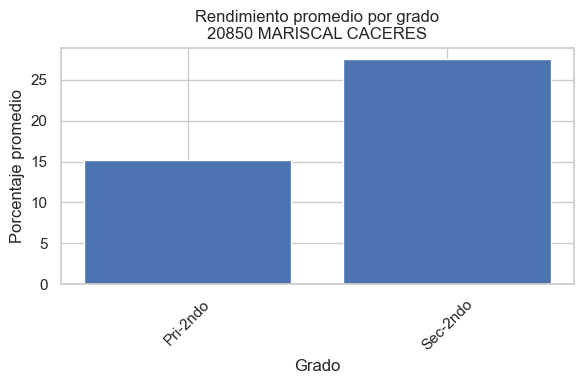

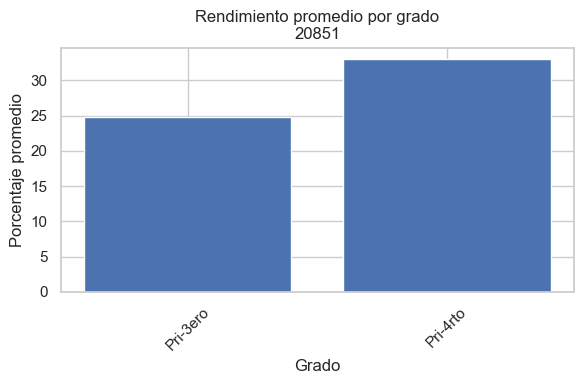

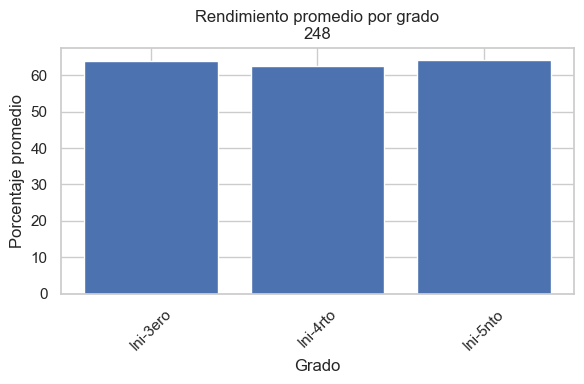

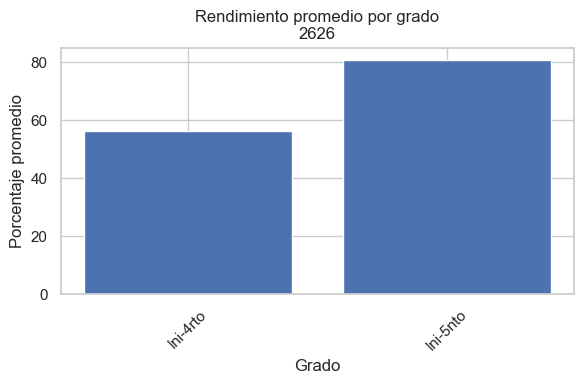

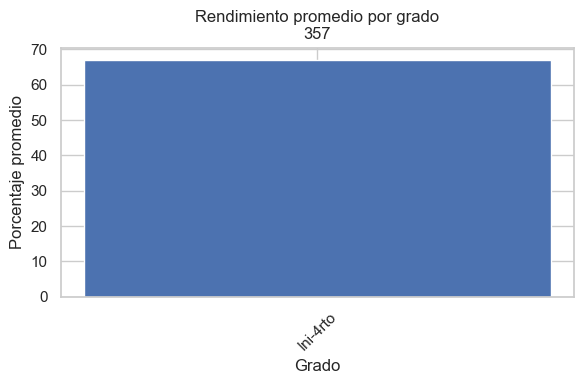

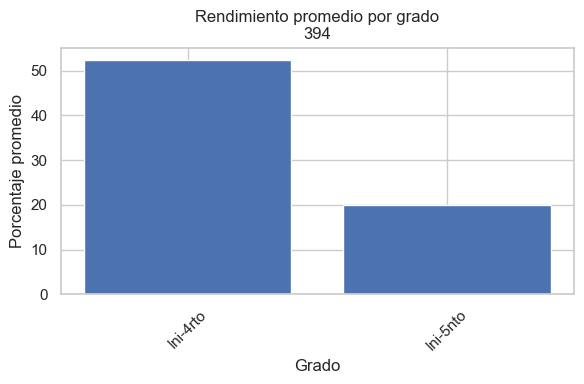

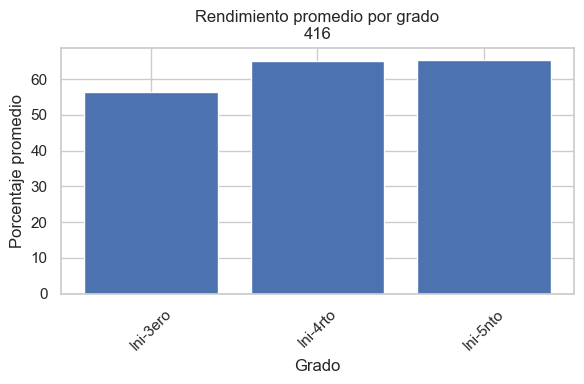

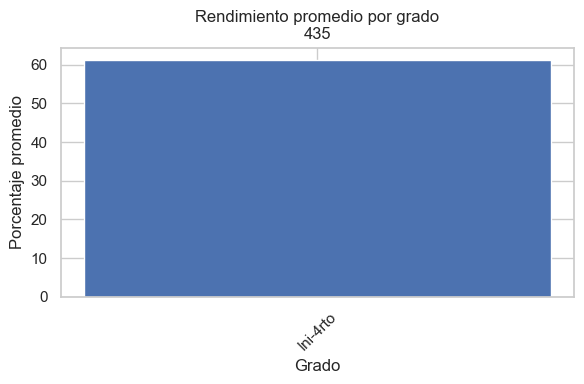

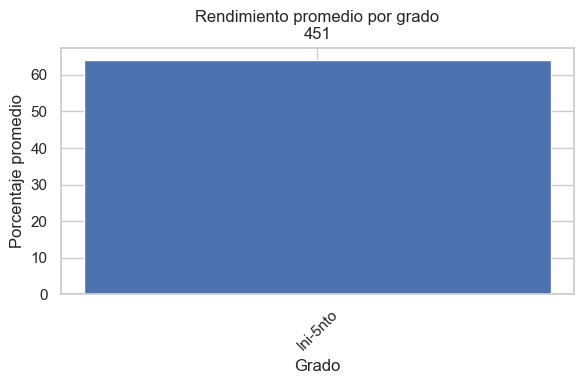

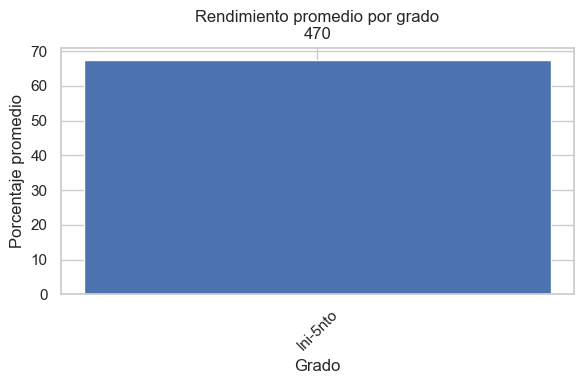

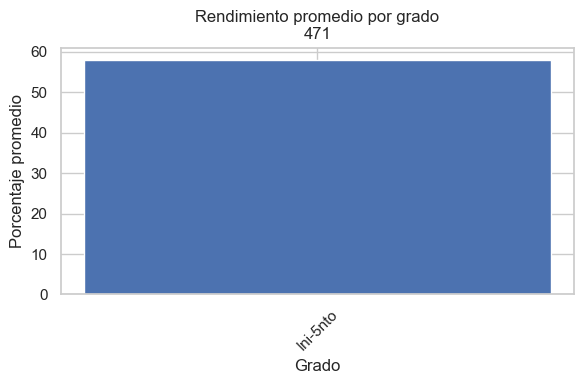

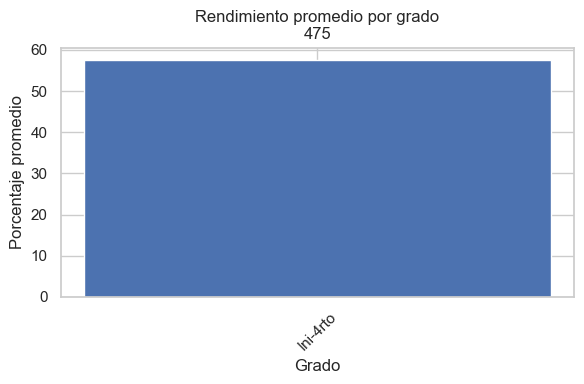

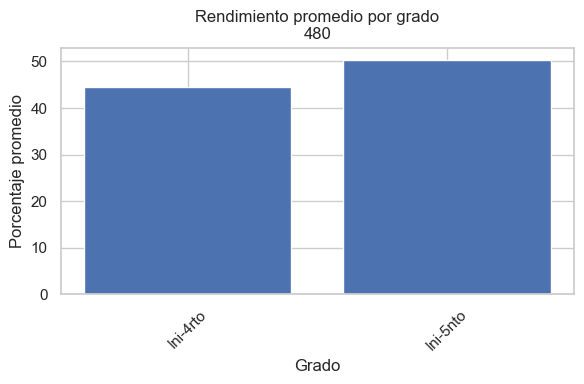

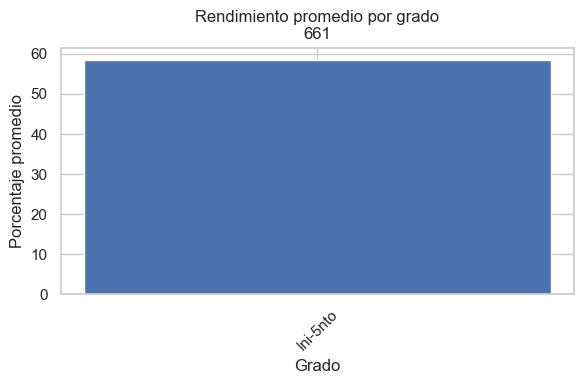

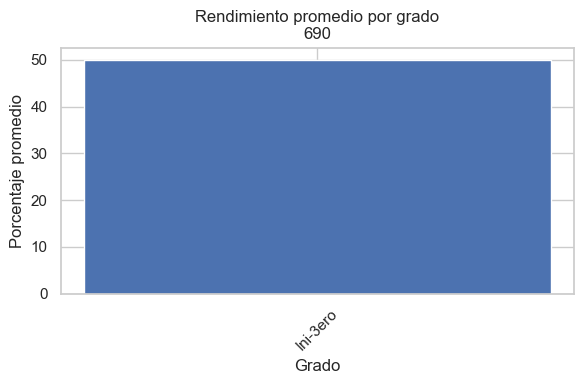

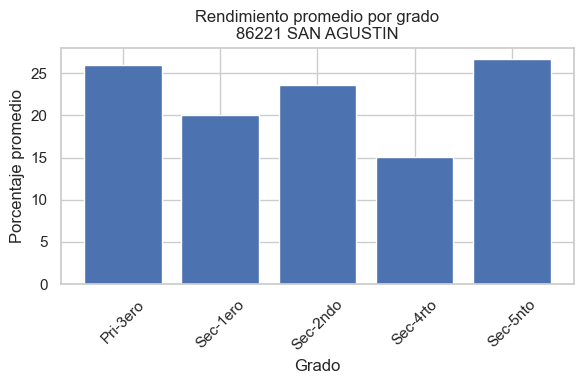

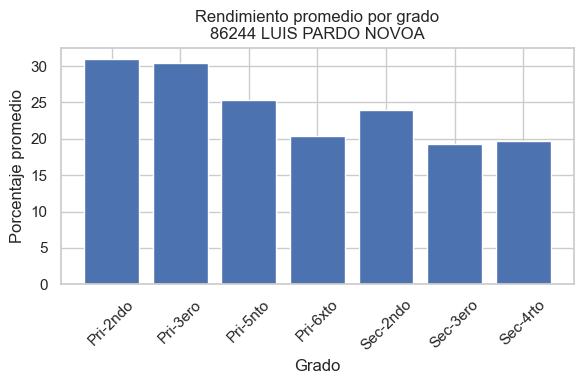

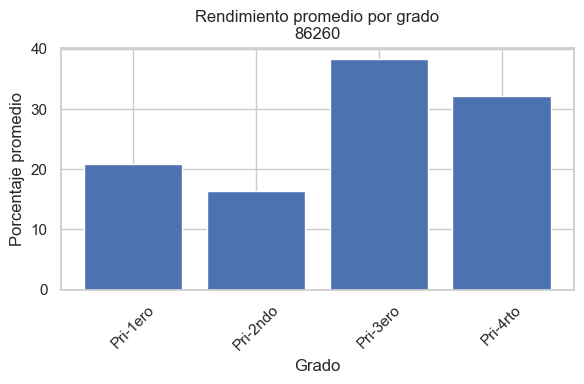

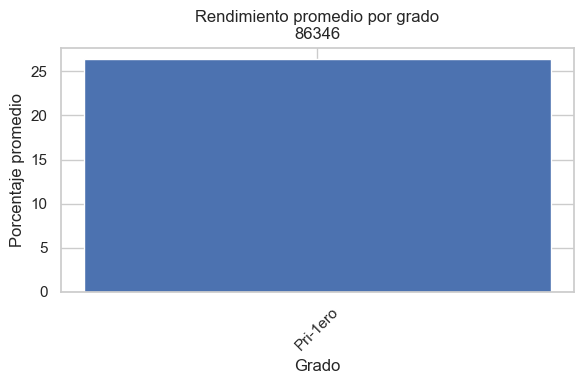

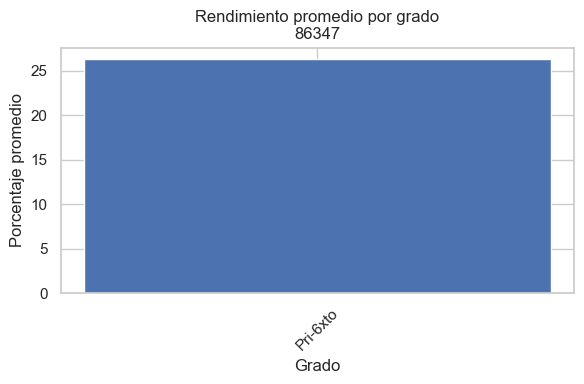

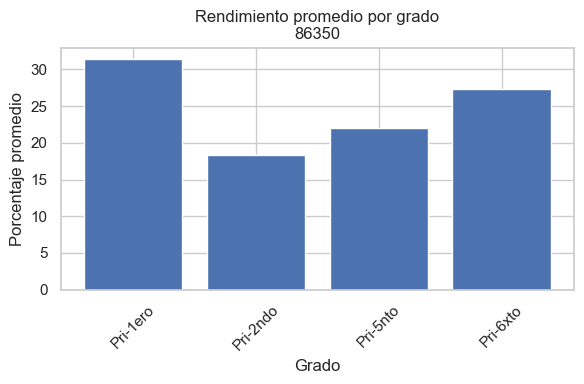

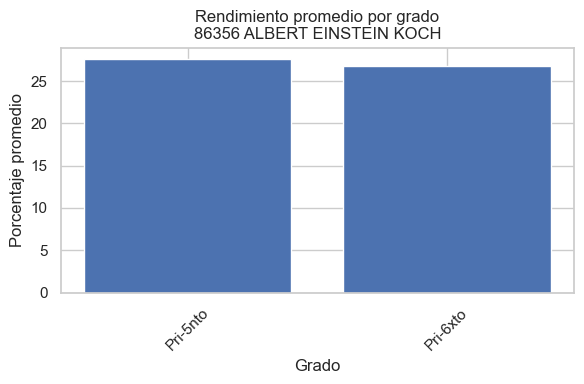

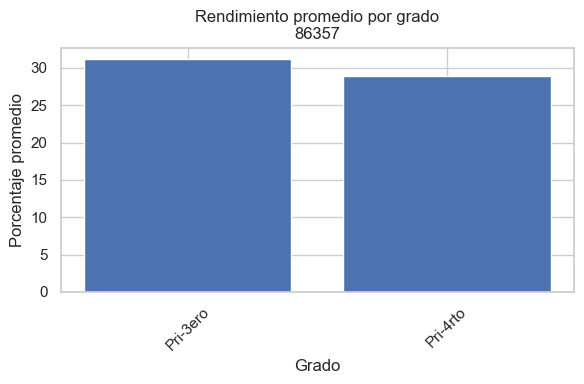

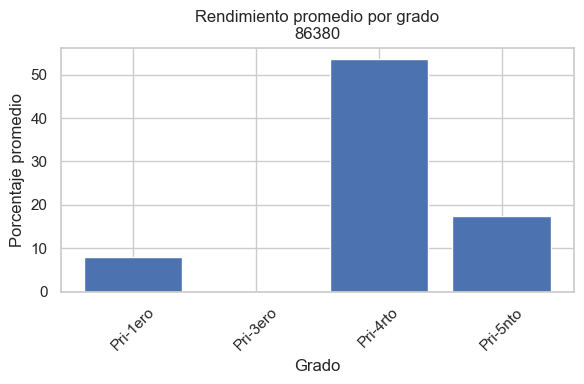

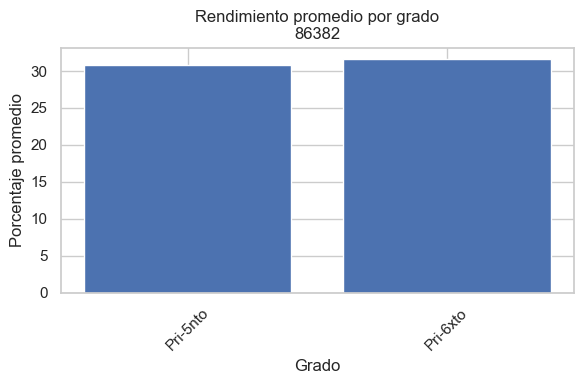

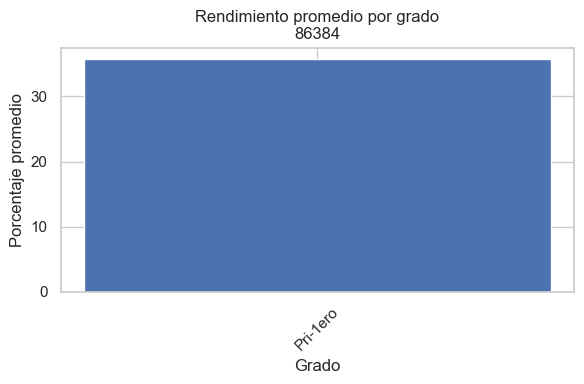

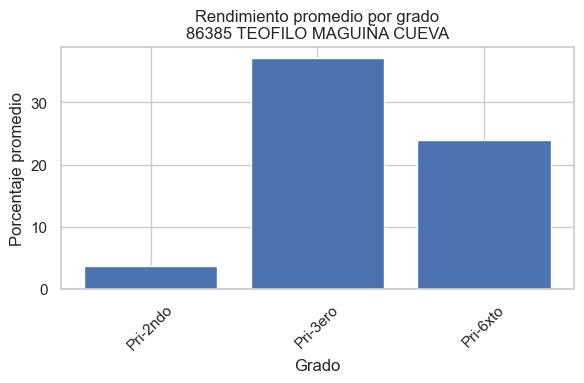

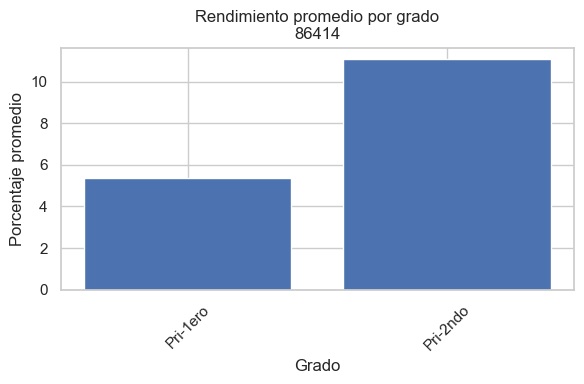

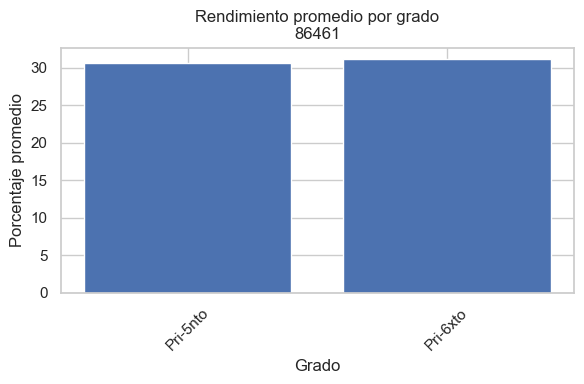

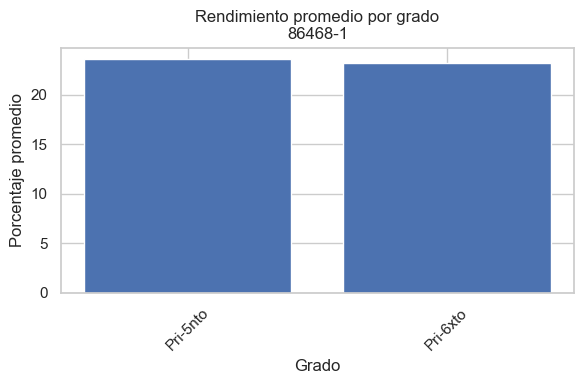

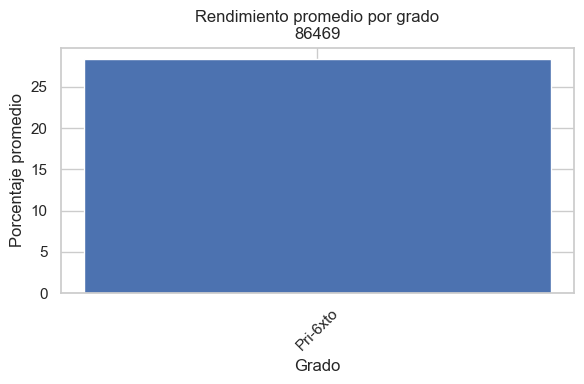

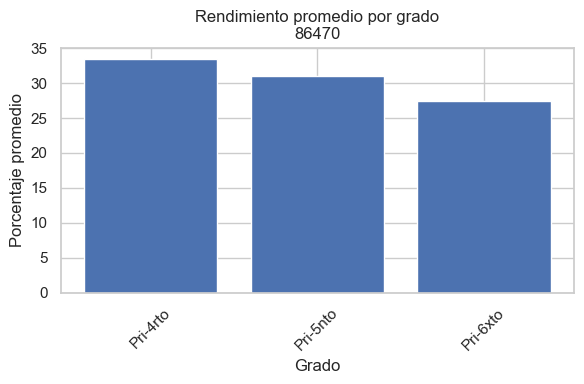

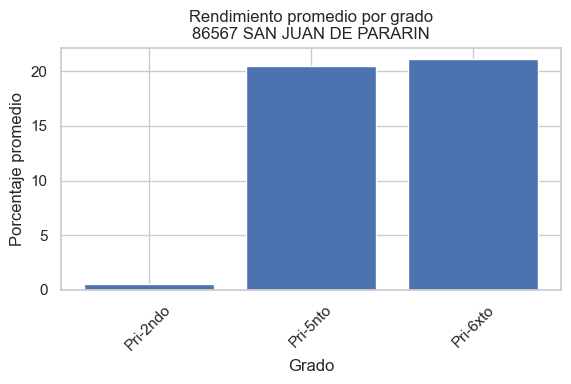

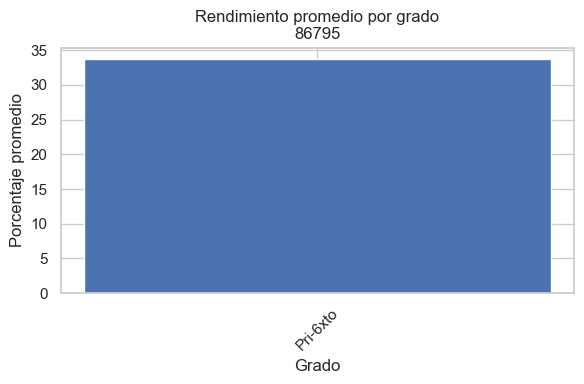

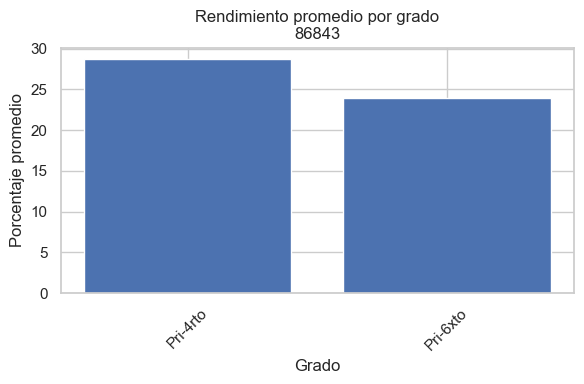

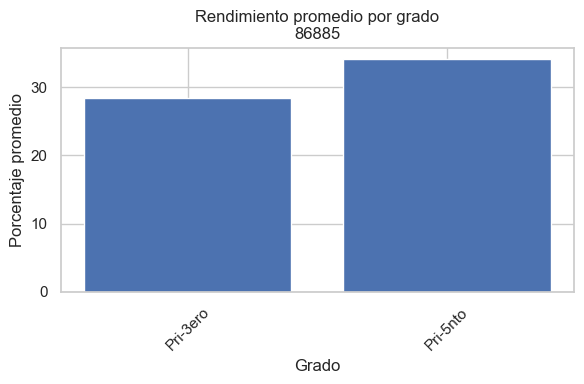

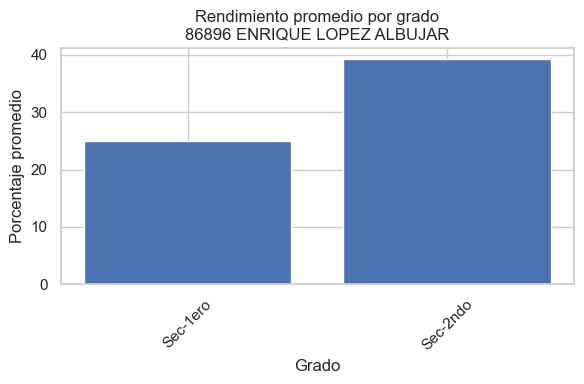

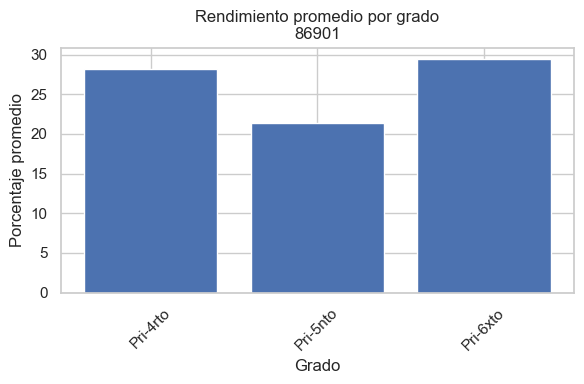

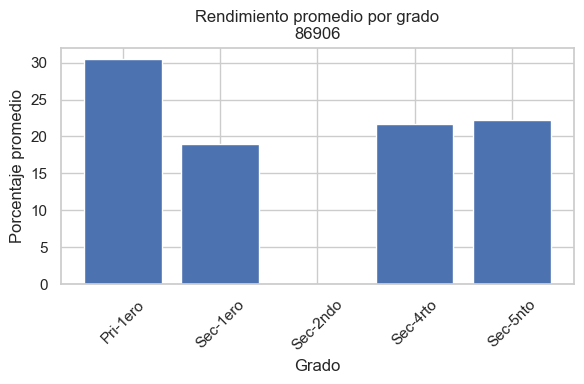

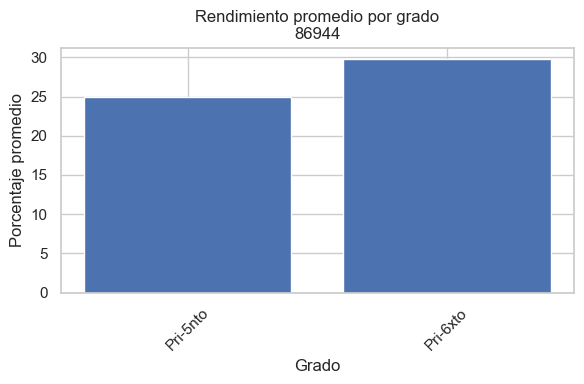

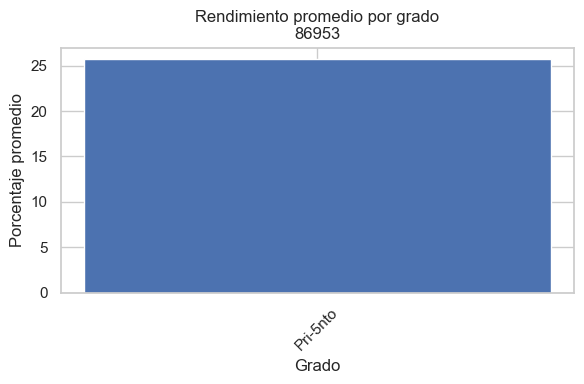

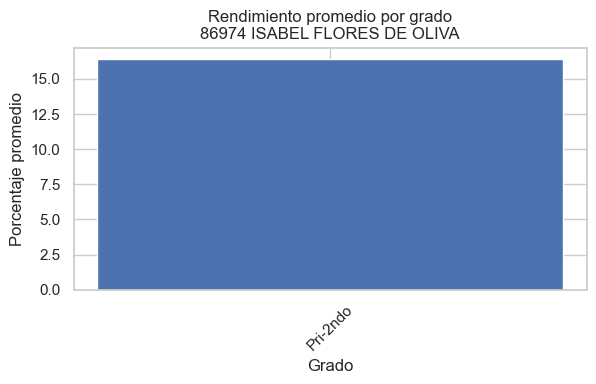

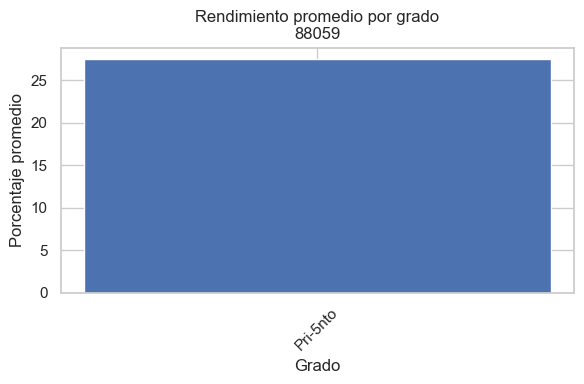

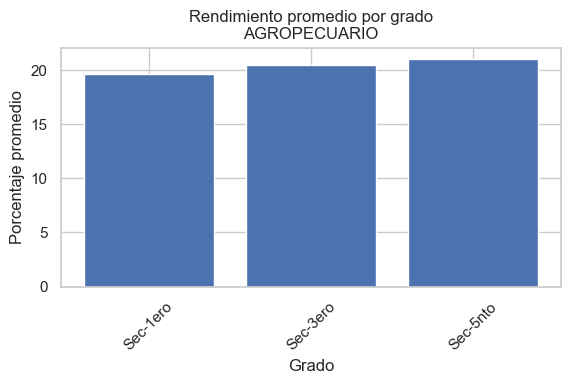

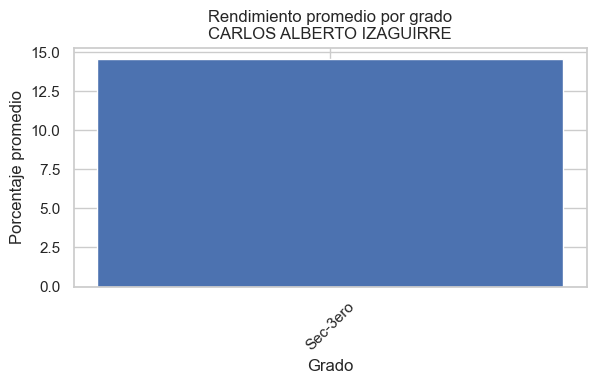

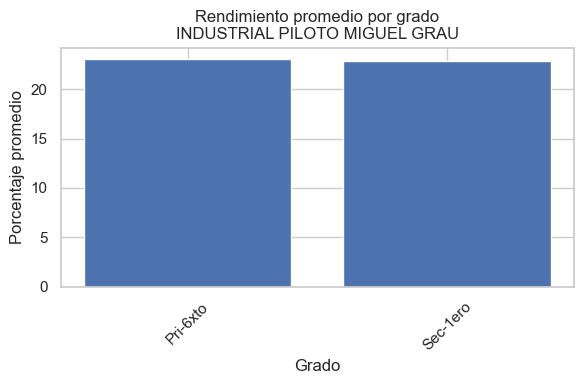

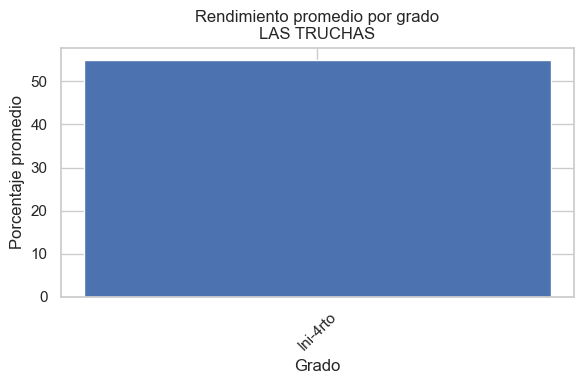

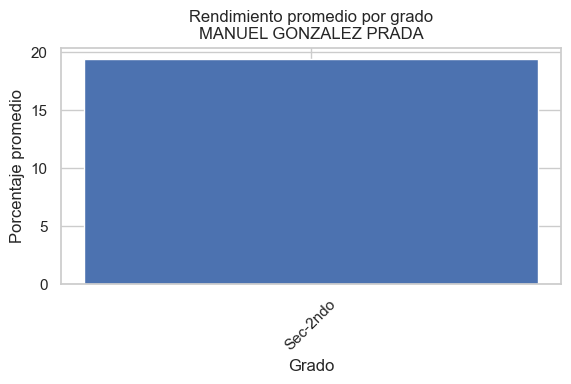

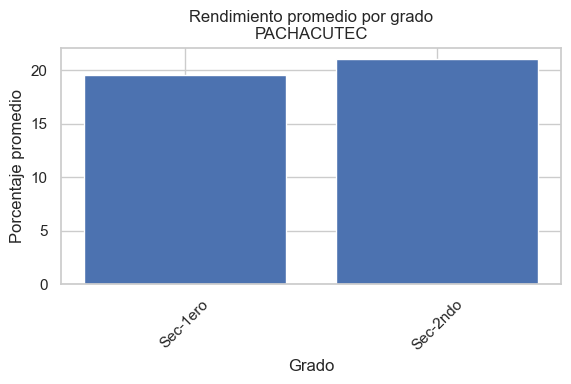

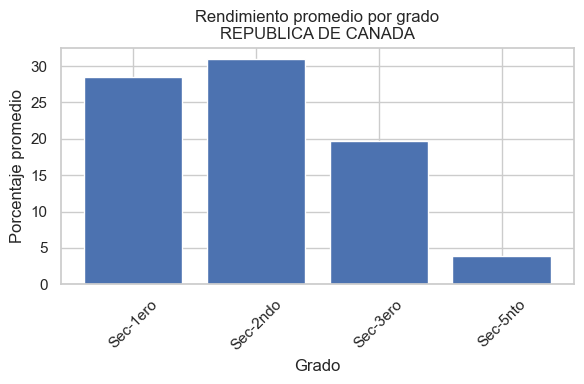

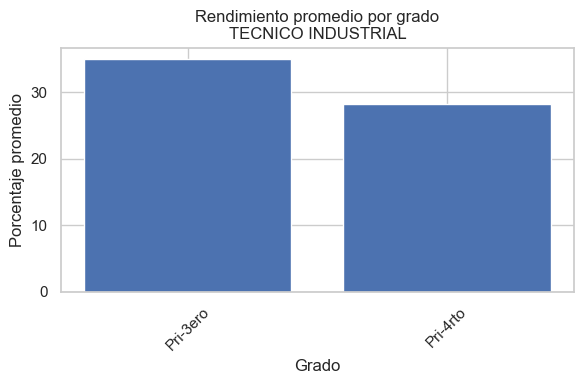

In [26]:
for colegio in colegios:
    
    df_temp = eda_escuelas[eda_escuelas['nom_ie'] == colegio]
    
    plt.figure(figsize=(6,4))
    
    plt.bar(
        df_temp['grado'],
        df_temp['porcentaje_promedio']
    )
    
    plt.title(f'Rendimiento promedio por grado\n{colegio}')
    plt.xlabel('Grado')
    plt.ylabel('Porcentaje promedio')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:
df_

## URMECEA

In [17]:
df_umercea = pd.read_excel(r'data\5_URMECEA-HISTÓRICO_lite.xlsx')

In [18]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df_umercea.head(3))

,Cod_Modular,Cod_Local,AÑO,Región,Ugel,Provincia,Distrito,Centro_Poblado,Nombre_IE,PDL DIRECTO,PDL INDIRECTO,PDL,QM DIRECTO,QM INDIRECTO,QM,PDLD,MTESANA,ACADEMIA,PFC,EPE,Nivel,Área,GRADO,Evaluación,Nivel de logro,PERIODO,UGT
0,358242,81,2024,Ancash,UGEL CORONGO,Corongo,Bambas,BAMBAS,88129 ERNESTO SANCHEZ FAJARDO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Primaria,Rural,4to,LECTURA,En Inicio,ENTRADA,NaN
1,417766,15308,2024,Ancash,UGEL HUARAZ,Huaraz,Huaraz,COILLOR / KEROPAMPA,86003 VIRGEN DE FATIMA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Primaria,Rural,4to,LECTURA,En Proceso,ENTRADA,NaN
2,417766,15308,2024,Ancash,UGEL HUARAZ,Huaraz,Huaraz,COILLOR / KEROPAMPA,86003 VIRGEN DE FATIMA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Primaria,Rural,4to,LECTURA,En Proceso,ENTRADA,NaN


In [22]:
df_umercea[df_umercea['QM']=='SI']['Nombre_IE'].value_counts()

Nombre_IE
CARLOS ALBERTO IZAGUIRRE       1051
PACHACUTEC                      840
86349 REPUBLICA DE HONDURAS     705
MANUEL GONZALEZ PRADA           554
86380                           458
                               ... 
86411                             6
86566 JULIO C. TELLO              4
86412                             4
86407                             4
86357                             2
Name: count, Length: 65, dtype: int64

In [29]:
df_umercea.describe()

,Cod_Modular,Cod_Local,AÑO
count,1.039100e+05,103910.000000,103910.000000
mean,6.149651e+05,69209.086844,2023.225561
std,3.461173e+05,155817.708828,0.834685
min,2.171250e+05,81.000000,2022.000000
25%,4.117360e+05,21535.000000,2022.000000
50%,4.180120e+05,25500.000000,2023.000000
75%,6.813790e+05,32794.000000,2024.000000
max,3.026598e+06,860518.000000,2024.000000
